### Week 1 - Picking Best Single Feature (Income - Spending)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score

In [2]:
# Reading data
acct_df = pd.read_parquet("data/q2-ucsd-acctDF.pqt")
cons_df = pd.read_parquet("data/q2-ucsd-consDF.pqt")
txn_df = pd.read_parquet("data/q2-ucsd-trxnDF.pqt")
cat_map_df = pd.read_csv("data/q2-ucsd-cat-map.csv")

### Visualize each dataframe

In [3]:
acct_df

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
0,3023,0,SAVINGS,2021-08-31,90.57
1,3023,1,CHECKING,2021-08-31,225.95
2,4416,2,SAVINGS,2022-03-31,15157.17
3,4416,3,CHECKING,2022-03-31,66.42
4,4227,4,CHECKING,2021-07-31,7042.90
...,...,...,...,...,...
24461,11500,24461,CHECKING,2022-03-27,732.75
24462,11615,24462,SAVINGS,2022-03-30,5.00
24463,11615,24463,CHECKING,2022-03-30,1956.46
24464,12210,24464,CHECKING,2022-03-28,2701.51


In [4]:
train_df = cons_df[cons_df['DQ_TARGET'].notna()]
train_df

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0
...,...,...,...,...
13995,13995,2022-01-22,802.0,0.0
13996,13996,2022-02-01,652.0,0.0
13997,13997,2021-12-24,765.0,0.0
13998,13998,2022-01-30,685.0,0.0


In [5]:
len(cons_df['prism_consumer_id'].unique())

15000

In [6]:
txn_df

,prism_consumer_id,prism_transaction_id,category,amount,credit_or_debit,posted_date
0,3023,0,4,0.05,CREDIT,2021-04-16
1,3023,1,12,481.56,CREDIT,2021-04-30
2,3023,2,4,0.05,CREDIT,2021-05-16
3,3023,3,4,0.07,CREDIT,2021-06-16
4,3023,4,4,0.06,CREDIT,2021-07-16
...,...,...,...,...,...,...
6407316,10533,6405304,31,4.96,DEBIT,2022-03-11
6407317,10533,6405305,12,63.48,DEBIT,2022-03-30
6407318,10533,6405306,12,53.99,DEBIT,2022-03-30
6407319,10533,6405307,12,175.98,DEBIT,2022-03-31


In [7]:
cat_map_df


,category_id,category
0,0,SELF_TRANSFER
1,1,EXTERNAL_TRANSFER
2,2,DEPOSIT
3,3,PAYCHECK
4,4,MISCELLANEOUS
5,5,PAYCHECK_PLACEHOLDER
6,6,REFUND
7,7,INVESTMENT_INCOME
8,8,OTHER_BENEFITS
9,9,UNEMPLOYMENT_BENEFITS


### Data Preprocessing

In [8]:
# Convert Category Mappings to a dictionary

cat_map = dict()

for i in range(cat_map_df.shape[0]):
    cat_map[i] = cat_map_df['category'].iloc[i]

cat_map

{0: 'SELF_TRANSFER',
 1: 'EXTERNAL_TRANSFER',
 2: 'DEPOSIT',
 3: 'PAYCHECK',
 4: 'MISCELLANEOUS',
 5: 'PAYCHECK_PLACEHOLDER',
 6: 'REFUND',
 7: 'INVESTMENT_INCOME',
 8: 'OTHER_BENEFITS',
 9: 'UNEMPLOYMENT_BENEFITS',
 10: 'SMALL_DOLLAR_ADVANCE',
 11: 'TAX',
 12: 'LOAN',
 13: 'INSURANCE',
 14: 'FOOD_AND_BEVERAGES',
 15: 'UNCATEGORIZED',
 16: 'GENERAL_MERCHANDISE',
 17: 'AUTOMOTIVE',
 18: 'GROCERIES',
 19: 'ATM_CASH',
 20: 'ENTERTAINMENT',
 21: 'TRAVEL',
 22: 'ESSENTIAL_SERVICES',
 23: 'ACCOUNT_FEES',
 24: 'HOME_IMPROVEMENT',
 25: 'OVERDRAFT',
 26: 'CREDIT_CARD_PAYMENT',
 27: 'HEALTHCARE_MEDICAL',
 28: 'PETS',
 29: 'EDUCATION',
 30: 'GIFTS_DONATIONS',
 31: 'BILLS_UTILITIES',
 32: 'MORTGAGE',
 33: 'CHILD_DEPENDENTS',
 34: 'RENT',
 35: 'BNPL',
 36: 'AUTO_LOAN',
 37: 'BANKING_CATCH_ALL',
 38: 'DEBT',
 39: 'FITNESS',
 40: 'TRANSPORATION',
 41: 'LEGAL',
 42: 'GOVERNMENT_SERVICES',
 43: 'RISK_CATCH_ALL',
 44: 'RTO_LTO',
 45: 'INVESTMENT',
 46: 'GAMBLING',
 47: 'CORPORATE_PAYMENTS',
 48: 'TIME_O

In [9]:
# Map all categories into the dataframe

txn_df['category'] = txn_df['category'].apply(lambda x: cat_map[x])

In [10]:
# Divide the transaction dataset into debit and credit

deb_txn = txn_df[txn_df['credit_or_debit'] == "DEBIT"]
cre_txn = txn_df[txn_df['credit_or_debit'] == "CREDIT"]

In [11]:
sum(deb_txn['amount'] < 0)

0

In [12]:
cre_txn[cre_txn['amount'] < 0]['category'].value_counts()

Series([], Name: count, dtype: int64)

In [13]:
cre_txn[cre_txn['amount'] > 0]['category'].value_counts()

category
SELF_TRANSFER            342392
EXTERNAL_TRANSFER        216021
PAYCHECK                 180208
DEPOSIT                  114156
MISCELLANEOUS            112397
REFUND                    60841
INVESTMENT_INCOME         21813
LOAN                      13585
TAX                       10262
UNEMPLOYMENT_BENEFITS      7521
INVESTMENT                 6684
PENSION                    6032
TIME_OR_STUFF              5660
OTHER_BENEFITS             5513
INSURANCE                  1432
GAMBLING                    424
CORPORATE_PAYMENTS           22
Name: count, dtype: int64

In [14]:
txn_df['category'].unique()

array(['MISCELLANEOUS', 'LOAN', 'EXTERNAL_TRANSFER', 'DEPOSIT',
       'SELF_TRANSFER', 'INVESTMENT', 'PAYCHECK', 'REFUND',
       'ENTERTAINMENT', 'FOOD_AND_BEVERAGES', 'GROCERIES', 'FITNESS',
       'GENERAL_MERCHANDISE', 'HEALTHCARE_MEDICAL', 'GAMBLING',
       'GIFTS_DONATIONS', 'CREDIT_CARD_PAYMENT', 'AUTOMOTIVE',
       'HOME_IMPROVEMENT', 'ATM_CASH', 'TRANSPORATION', 'PENSION',
       'INSURANCE', 'TAX', 'ACCOUNT_FEES', 'RENT', 'BILLS_UTILITIES',
       'ESSENTIAL_SERVICES', 'EDUCATION', 'TRAVEL', 'PETS', 'MORTGAGE',
       'BANKING_CATCH_ALL', 'DEBT', 'AUTO_LOAN', 'BNPL',
       'GOVERNMENT_SERVICES', 'CORPORATE_PAYMENTS', 'LEGAL',
       'RISK_CATCH_ALL', 'OTHER_BENEFITS', 'TIME_OR_STUFF',
       'UNEMPLOYMENT_BENEFITS', 'CHILD_DEPENDENTS', 'RTO_LTO',
       'INVESTMENT_INCOME', 'OVERDRAFT'], dtype=object)

In [43]:
train_ids = set(train_df['prism_consumer_id'])

In [49]:
txn_df = txn_df[txn_df['prism_consumer_id'].isin(train_ids)]

### Feature Engineering

To find the best feature, I am trying to aggregate the transaction df on consumer-level and get a feature (net monthly income) that represent "estimated monthly income" - "estimated monthly spending".

In [50]:
# Aggregate transaction amount based on individual consumer and year-month pair

txn_df['year_month'] = pd.to_datetime(txn_df['posted_date']).dt.to_period('M')

txn_aggregated = txn_df.groupby(['prism_consumer_id', 'year_month']).agg(
    monthly_income=('amount', lambda x: x[txn_df.loc[x.index, 'credit_or_debit'] == 'CREDIT'].sum()),
    monthly_spending=('amount', lambda x: x[txn_df.loc[x.index, 'credit_or_debit'] == 'DEBIT'].sum())
).reset_index()

txn_aggregated

/var/folders/2f/pp48ygln7m9cxl6lrzd_n_t40000gn/T/ipykernel_36929/1869964079.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  txn_df['year_month'] = pd.to_datetime(txn_df['posted_date']).dt.to_period('M')


,prism_consumer_id,year_month,monthly_income,monthly_spending
0,0,2021-03,2400.69,1999.35
1,0,2021-04,3210.66,2379.93
2,0,2021-05,967.00,765.50
3,0,2021-06,1068.13,3652.37
4,0,2021-07,2204.83,2276.21
...,...,...,...,...
71780,999,2020-11,3657.41,3050.31
71781,999,2020-12,4067.41,4425.33
71782,999,2021-01,5047.99,5485.97
71783,999,2021-02,10123.39,7895.62


In [51]:
txn_aggregated['monthly_net_income'] = txn_aggregated.apply(lambda row: row['monthly_income'] - row['monthly_spending'], axis = 1)
txn_aggregated

,prism_consumer_id,year_month,monthly_income,monthly_spending,monthly_net_income
0,0,2021-03,2400.69,1999.35,401.34
1,0,2021-04,3210.66,2379.93,830.73
2,0,2021-05,967.00,765.50,201.50
3,0,2021-06,1068.13,3652.37,-2584.24
4,0,2021-07,2204.83,2276.21,-71.38
...,...,...,...,...,...
71780,999,2020-11,3657.41,3050.31,607.10
71781,999,2020-12,4067.41,4425.33,-357.92
71782,999,2021-01,5047.99,5485.97,-437.98
71783,999,2021-02,10123.39,7895.62,2227.77


In [52]:
txn_avg_monthly = txn_aggregated.groupby('prism_consumer_id').agg(
    average_nmi=('monthly_net_income', 'mean')
).reset_index()

txn_avg_monthly

,prism_consumer_id,average_nmi
0,0,-74.512857
1,1,257.918571
2,10,-170.005714
3,100,-750.961667
4,1000,62.582857
...,...,...
11596,995,3120.382857
11597,996,3816.168571
11598,997,-2128.522857
11599,998,786.818571


In [53]:
def zscoring_normalize(df, column):
    # Calculate the mean and standard deviation of the entire balance column
    mean = df[column].mean()
    std = df[column].std()

    # Z-score normalization
    df[column + '_z_score'] = (df[column] - mean) / std

In [54]:
txn_avg_monthly

zscoring_normalize(txn_avg_monthly, 'average_nmi')

In [55]:
txn_cons = set(txn_avg_monthly['prism_consumer_id'].unique())
cons_cons = set(cons_df['prism_consumer_id'].unique())

len(cons_cons - txn_cons)

3399

In [56]:
cons_cons - txn_cons

{'4410',
 '4534',
 '9451',
 '14357',
 '7101',
 '14549',
 '9191',
 '9610',
 '4958',
 '14724',
 '14975',
 '14494',
 '9103',
 '14141',
 '14137',
 '4817',
 '14879',
 '4455',
 '14117',
 '4144',
 '9022',
 '4173',
 '4903',
 '14698',
 '7394',
 '14128',
 '4231',
 '4242',
 '14731',
 '14252',
 '14462',
 '14814',
 '14677',
 '8083',
 '6460',
 '14882',
 '4383',
 '9979',
 '4174',
 '14931',
 '9705',
 '14616',
 '5878',
 '4648',
 '4379',
 '14666',
 '4759',
 '4052',
 '14087',
 '9404',
 '9855',
 '4464',
 '7596',
 '14920',
 '9220',
 '9201',
 '6882',
 '9802',
 '9795',
 '4036',
 '7900',
 '5588',
 '9298',
 '9079',
 '9914',
 '4044',
 '9378',
 '4005',
 '9655',
 '9880',
 '14960',
 '4769',
 '4404',
 '4682',
 '4284',
 '14942',
 '7407',
 '14803',
 '9973',
 '4013',
 '7302',
 '14266',
 '14785',
 '9112',
 '4069',
 '6948',
 '4504',
 '9686',
 '4766',
 '5506',
 '14486',
 '4904',
 '9604',
 '14418',
 '9794',
 '4960',
 '4580',
 '4222',
 '4969',
 '4392',
 '14991',
 '4911',
 '14360',
 '14373',
 '10234',
 '9774',
 '14845',
 '9

In [57]:
cons_txn_merged = cons_df.merge(txn_avg_monthly, on='prism_consumer_id', how='left')

In [58]:
train_df = train_df[['prism_consumer_id', 'DQ_TARGET']]

In [59]:
#txn_df['year_month'] = pd.to_datetime(txn_df['posted_date']).dt.to_period('M')
acct_df['year_month'] = pd.to_datetime(acct_df['balance_date']).dt.to_period('M')
acct_df

,prism_consumer_id,prism_account_id,account_type,balance_date,balance,year_month
0,3023,0,SAVINGS,2021-08-31,90.57,2021-08
1,3023,1,CHECKING,2021-08-31,225.95,2021-08
2,4416,2,SAVINGS,2022-03-31,15157.17,2022-03
3,4416,3,CHECKING,2022-03-31,66.42,2022-03
4,4227,4,CHECKING,2021-07-31,7042.90,2021-07
...,...,...,...,...,...,...
24461,11500,24461,CHECKING,2022-03-27,732.75,2022-03
24462,11615,24462,SAVINGS,2022-03-30,5.00,2022-03
24463,11615,24463,CHECKING,2022-03-30,1956.46,2022-03
24464,12210,24464,CHECKING,2022-03-28,2701.51,2022-03


In [60]:
txn_df

,prism_consumer_id,prism_transaction_id,category,amount,credit_or_debit,posted_date,year_month
0,3023,0,MISCELLANEOUS,0.05,CREDIT,2021-04-16,2021-04
1,3023,1,LOAN,481.56,CREDIT,2021-04-30,2021-04
2,3023,2,MISCELLANEOUS,0.05,CREDIT,2021-05-16,2021-05
3,3023,3,MISCELLANEOUS,0.07,CREDIT,2021-06-16,2021-06
4,3023,4,MISCELLANEOUS,0.06,CREDIT,2021-07-16,2021-07
...,...,...,...,...,...,...,...
6407316,10533,6405304,BILLS_UTILITIES,4.96,DEBIT,2022-03-11,2022-03
6407317,10533,6405305,LOAN,63.48,DEBIT,2022-03-30,2022-03
6407318,10533,6405306,LOAN,53.99,DEBIT,2022-03-30,2022-03
6407319,10533,6405307,LOAN,175.98,DEBIT,2022-03-31,2022-03


## WEEK 2 - Balance and Income

credit = inflow, debit = outflow

In [61]:
txn = txn_aggregated.copy()
txn

,prism_consumer_id,year_month,monthly_income,monthly_spending,monthly_net_income
0,0,2021-03,2400.69,1999.35,401.34
1,0,2021-04,3210.66,2379.93,830.73
2,0,2021-05,967.00,765.50,201.50
3,0,2021-06,1068.13,3652.37,-2584.24
4,0,2021-07,2204.83,2276.21,-71.38
...,...,...,...,...,...
71780,999,2020-11,3657.41,3050.31,607.10
71781,999,2020-12,4067.41,4425.33,-357.92
71782,999,2021-01,5047.99,5485.97,-437.98
71783,999,2021-02,10123.39,7895.62,2227.77


In [62]:
txn = txn[['prism_consumer_id', 'year_month', 'monthly_net_income']]
txn

,prism_consumer_id,year_month,monthly_net_income
0,0,2021-03,401.34
1,0,2021-04,830.73
2,0,2021-05,201.50
3,0,2021-06,-2584.24
4,0,2021-07,-71.38
...,...,...,...
71780,999,2020-11,607.10
71781,999,2020-12,-357.92
71782,999,2021-01,-437.98
71783,999,2021-02,2227.77


In [63]:
balance_df = acct_df.groupby(['prism_consumer_id', 'year_month']).agg(balance = ('balance', 'sum')).reset_index()
balance_df

,prism_consumer_id,year_month,balance
0,0,2021-08,320.37
1,1,2021-06,3302.42
2,10,2022-01,824.24
3,100,2021-04,802.40
4,100,2022-12,1853.07
...,...,...,...
13294,9995,2023-03,0.00
13295,9996,2023-10,252.67
13296,9997,2023-05,611.28
13297,9998,2023-11,-862.99


In [64]:
txn['cumulative_inflow'] = txn.groupby('prism_consumer_id')['monthly_net_income'].cumsum()
txn

/var/folders/2f/pp48ygln7m9cxl6lrzd_n_t40000gn/T/ipykernel_36929/3326790012.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  txn['cumulative_inflow'] = txn.groupby('prism_consumer_id')['monthly_net_income'].cumsum()


,prism_consumer_id,year_month,monthly_net_income,cumulative_inflow
0,0,2021-03,401.34,401.34
1,0,2021-04,830.73,1232.07
2,0,2021-05,201.50,1433.57
3,0,2021-06,-2584.24,-1150.67
4,0,2021-07,-71.38,-1222.05
...,...,...,...,...
71780,999,2020-11,607.10,433.48
71781,999,2020-12,-357.92,75.56
71782,999,2021-01,-437.98,-362.42
71783,999,2021-02,2227.77,1865.35


In [103]:
merged = pd.merge(txn, balance_df[['prism_consumer_id','balance', 'year_month']], 
                  on='prism_consumer_id', how='left')
merged

,prism_consumer_id,year_month_x,monthly_net_income,cumulative_inflow,balance,year_month_y
0,0,2021-03,401.34,401.34,320.37,2021-08
1,0,2021-04,830.73,1232.07,320.37,2021-08
2,0,2021-05,201.50,1433.57,320.37,2021-08
3,0,2021-06,-2584.24,-1150.67,320.37,2021-08
4,0,2021-07,-71.38,-1222.05,320.37,2021-08
...,...,...,...,...,...,...
73326,999,2020-11,607.10,433.48,2236.37,2021-02
73327,999,2020-12,-357.92,75.56,2236.37,2021-02
73328,999,2021-01,-437.98,-362.42,2236.37,2021-02
73329,999,2021-02,2227.77,1865.35,2236.37,2021-02


In [104]:

def find_real_start_balance(grp):
    """
    Given all rows for one consumer, find their earliest known 'balance' 
    (the 'anchor'), and compute the 'start' balance at the earliest 
    transaction date by subtracting inflows that happened before that anchor.
    """
    # 1) Identify the earliest "anchor" row where we actually have a known balance
    #    i.e. the earliest balance_month (year_month_y) that is not NaN.
    anchor_rows = grp.dropna(subset=["balance"]).sort_values("year_month_y")
    if anchor_rows.empty:
        # If there's no known balance at all for this consumer, return NaN or 0
        return pd.Series({"start_balance": float(0)})

    anchor_balance = anchor_rows["balance"].iloc[0]
    anchor_month   = anchor_rows["year_month_y"].iloc[0]
    
    # 2) Sum up all inflows that happened *before* that anchor month
    inflow_before_anchor = grp.loc[
        grp["year_month_x"] <= anchor_month, 
        "monthly_net_income"
    ].sum()
    
    # 3) The "real start" at the earliest transaction month = 
    #    (anchor balance) - (any inflows from earliest txn up to anchor−1)
    start_balance = anchor_balance - inflow_before_anchor
    
    # Return as a Series so we can keep it in a column
    return pd.Series({"start_balance": start_balance})

# Now group by consumer and apply the function above.
real_starts = (
    merged
    .groupby("prism_consumer_id", group_keys=False)
    .apply(find_real_start_balance)
    .reset_index()
)

real_starts

/var/folders/2f/pp48ygln7m9cxl6lrzd_n_t40000gn/T/ipykernel_36929/3341223868.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(find_real_start_balance)


,prism_consumer_id,start_balance
0,0,1375.24
1,1,556.26
2,10,1934.32
3,100,802.40
4,1000,136.28
...,...,...
11596,995,75058.94
11597,996,-71753.00
11598,997,78054.56
11599,998,364.29


In [105]:
merged = pd.merge(txn, real_starts[['prism_consumer_id','start_balance']], 
                  on='prism_consumer_id', how='left')

merged

,prism_consumer_id,year_month,monthly_net_income,cumulative_inflow,start_balance
0,0,2021-03,401.34,401.34,1375.24
1,0,2021-04,830.73,1232.07,1375.24
2,0,2021-05,201.50,1433.57,1375.24
3,0,2021-06,-2584.24,-1150.67,1375.24
4,0,2021-07,-71.38,-1222.05,1375.24
...,...,...,...,...,...
71780,999,2020-11,607.10,433.48,371.02
71781,999,2020-12,-357.92,75.56,371.02
71782,999,2021-01,-437.98,-362.42,371.02
71783,999,2021-02,2227.77,1865.35,371.02


In [106]:
merged[merged['start_balance'].isna()]

,prism_consumer_id,year_month,monthly_net_income,cumulative_inflow,start_balance


In [107]:
merged[merged['prism_consumer_id'] == '10002']

,prism_consumer_id,year_month,monthly_net_income,cumulative_inflow,start_balance
51,10002,2021-05,-159.06,-159.06,0.0
52,10002,2021-06,-107.33,-266.39,0.0
53,10002,2021-07,1870.85,1604.46,0.0
54,10002,2021-08,-1492.80,111.66,0.0
55,10002,2021-09,-120.88,-9.22,0.0
56,10002,2021-10,-257.77,-266.99,0.0
57,10002,2021-11,103.07,-163.92,0.0
58,10002,2021-12,701.72,537.80,0.0
59,10002,2022-01,-636.07,-98.27,0.0


In [108]:
acct_df[acct_df['prism_account_id'] == '10002']

,prism_consumer_id,prism_account_id,account_type,balance_date,balance,year_month
10002,5313,10002,CHECKING,2023-09-08,1521.82,2023-09


In [109]:
merged['monthly_balance'] = merged['cumulative_inflow'] + merged['start_balance']
monthly_balance_df = merged[['prism_consumer_id', 'year_month', 'monthly_balance']]
monthly_balance_df

,prism_consumer_id,year_month,monthly_balance
0,0,2021-03,1776.58
1,0,2021-04,2607.31
2,0,2021-05,2808.81
3,0,2021-06,224.57
4,0,2021-07,153.19
...,...,...,...
71780,999,2020-11,804.50
71781,999,2020-12,446.58
71782,999,2021-01,8.60
71783,999,2021-02,2236.37


In [ ]:
monthly_balance_df

In [110]:
balance_dq = pd.merge(monthly_balance_df, train_df[['prism_consumer_id','DQ_TARGET']], 
                  on='prism_consumer_id', how='left')


In [111]:
balance_dq[balance_dq['monthly_balance'].isna()]

,prism_consumer_id,year_month,monthly_balance,DQ_TARGET


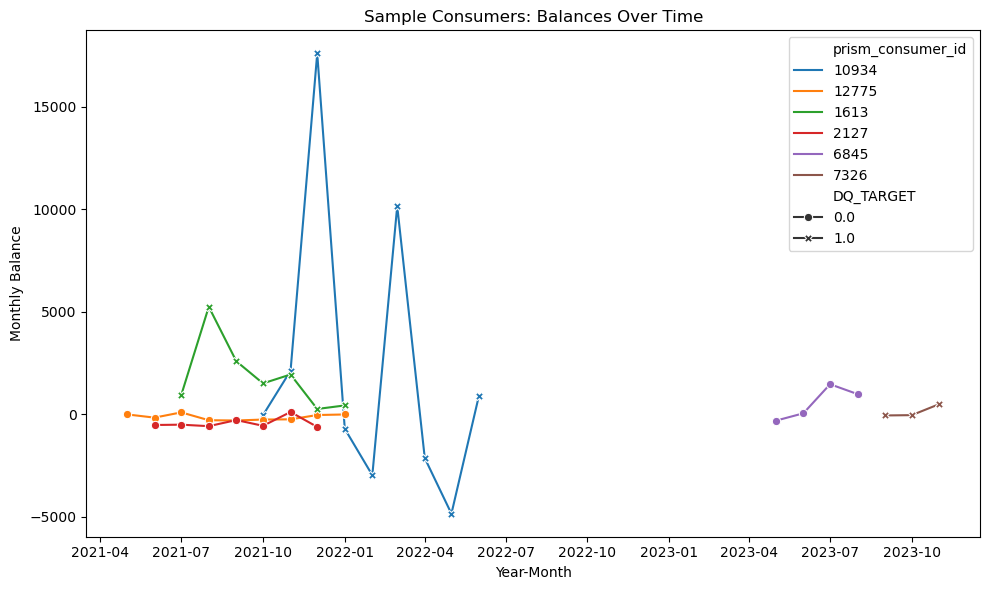

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separate good & bad
good_ids = balance_dq.loc[balance_dq['DQ_TARGET'] == 0, 'prism_consumer_id'].unique()
bad_ids  = balance_dq.loc[balance_dq['DQ_TARGET'] == 1, 'prism_consumer_id'].unique()

# 2. Randomly pick a few from each
np.random.seed(3)  # for reproducible results
sample_good = np.random.choice(good_ids, size=3, replace=False)
sample_bad  = np.random.choice(bad_ids, size=3, replace=False)

sample_ids = list(sample_good) + list(sample_bad)

# 3. Filter your df to those IDs
df_plot = balance_dq[balance_dq['prism_consumer_id'].isin(sample_ids)].copy()

# If 'year_month' is Period type, convert to a datetime (start of month)
df_plot['year_month'] = df_plot['year_month'].dt.to_timestamp()

# Sort by consumer, then date
df_plot = df_plot.sort_values(['prism_consumer_id','year_month'])

# 4. Plot
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_plot,
    x='year_month',
    y='monthly_balance',
    hue='prism_consumer_id',  # different color per consumer
    style='DQ_TARGET',        # different line/marker for good vs bad
    markers=True,             # show markers
    dashes=False              # keep lines solid, only marker changes
)
plt.title('Sample Consumers: Balances Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Monthly Balance')
plt.tight_layout()
plt.show()


In [113]:
df_plot

,prism_consumer_id,year_month,monthly_balance,DQ_TARGET
11807,11276,2021-11,-263.65,0.0
11808,11276,2021-12,-663.68,0.0
11809,11276,2022-01,-2013.58,0.0
11810,11276,2022-02,-2215.86,0.0
13297,11445,2021-05,321.37,1.0
13298,11445,2021-06,1131.11,1.0
13299,11445,2021-07,186.18,1.0
13300,11445,2021-08,24.25,1.0
13301,11445,2021-09,1378.05,1.0
13302,11445,2021-10,910.87,1.0


In [87]:
txn[txn['prism_consumer_id'] == '11276']

,prism_consumer_id,year_month,monthly_net_income,cumulative_inflow
11807,11276,2021-11,-263.65,-263.65
11808,11276,2021-12,-400.03,-663.68
11809,11276,2022-01,-1349.90,-2013.58
11810,11276,2022-02,-202.28,-2215.86


In [76]:
df_plot.dtypes


prism_consumer_id       object
year_month           period[M]
monthly_balance        float64
DQ_TARGET              float64
dtype: object

In [80]:
df_plot[pd.to_numeric(df_plot["monthly_balance"], errors="coerce").isna()]


,prism_consumer_id,year_month,monthly_balance,DQ_TARGET


# Model Training

In [89]:
# Define a function to train Logistic Regression on a dataframe
def train_logistic_regression(df):
    """
    Train a logistic regression model using all columns (except the first) to predict the first column.

    Args:
        df (pd.DataFrame): Input dataframe where the first column (excluding index) is the target variable.

    Returns:
        None: Prints model evaluation metrics.
    """
    # Ensure the dataframe has at least two columns
    if df.shape[1] < 2:
        raise ValueError("The dataframe must have at least two columns.")
    
    temp = train_df.merge(df, on='prism_consumer_id', how='left')
    temp = temp.dropna()
    temp = temp.drop(columns=['prism_consumer_id'])

    # Separate features (X) and target (y)
    y = temp['DQ_TARGET']
    X = temp.drop(columns=['DQ_TARGET'])

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

    # Train Logistic Regression
    clf = LogisticRegression(random_state=0, max_iter=1000, class_weight="balanced")
    clf.fit(X_train, y_train)

    # Predict probabilities and classes
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_proba)

    print("Accuracy:", accuracy)
    print("F1 Score:", f1)
    print("AUC-ROC Score:", auc)
    print("Classification Report:\n", classification_report(y_test, y_pred))

In [85]:
# Normalized Average Net Monthly Inflow

train_logistic_regression(txn_avg_monthly[['prism_consumer_id', 'average_nmi_z_score']])

Accuracy: 0.9171523730224813
F1 Score: 0.8779169729170678
AUC-ROC Score: 0.5656485453445526
Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      1.00      0.96      2204
         1.0       0.00      0.00      0.00       198

    accuracy                           0.92      2402
   macro avg       0.46      0.50      0.48      2402
weighted avg       0.84      0.92      0.88      2402



In [92]:
# Normalized balance
acct_balance_df = acct_df.groupby("prism_consumer_id").agg(balance_sum = ('balance', 'sum')).reset_index()

zscoring_normalize(acct_balance_df, 'balance_sum')

train_logistic_regression(acct_balance_df[['prism_consumer_id', 'balance_sum_z_score']])

Accuracy: 0.3793254489706526
F1 Score: 0.46760211409791264
AUC-ROC Score: 0.7389294932217358
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.33      0.49      2089
         1.0       0.11      0.92      0.20       194

    accuracy                           0.38      2283
   macro avg       0.55      0.63      0.35      2283
weighted avg       0.91      0.38      0.47      2283



In [118]:
acct_df[acct_df["prism_consumer_id"] == '11615']

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
24462,11615,24462,SAVINGS,2022-03-30,5.00
24463,11615,24463,CHECKING,2022-03-30,1956.46
24465,11615,24465,CHECKING,2022-03-30,7967.45


In [115]:
acct_df["prism_consumer_id"][0]

'3023'

In [117]:
acct_df["prism_consumer_id"]

0         3023
1         3023
2         4416
3         4416
4         4227
         ...  
24461    11500
24462    11615
24463    11615
24464    12210
24465    11615
Name: prism_consumer_id, Length: 24466, dtype: object